In [1]:
import numpy as np
import pandas as pd
# Mô phỏng dữ liệu x và y theo một mô hình nào đó sau đó ước lượng mô hình trên dữ liệu tạo ra xem độ chính xác của mô hình ra sao
np.random.seed(123)
#
N = 1000 # tạo ra 1000 quan sát
beta_vec = np.array([-2, 0.5, 0.2]) # Véc tơ hệ số
#
x1 = np.random.normal(loc = 2, scale = 1, size = N)
x2 = np.random.normal(loc = 10, scale = 2, size = N)
#
eta = np.column_stack((np.ones(N), x1, x2)).dot(beta_vec)
prob= 1 / (1 + np.exp(-eta))
#
y = np.random.binomial(p = prob, n = 1, size = N)
#
data_mat = pd.DataFrame((y, x1, x2), index = ["y", "x1", "x2"]).T

In [5]:
data_mat.head(20)


,y,x1,x2
0,1.0,0.914369,8.502345
1,1.0,2.997345,11.135189
2,1.0,2.282978,11.436301
3,1.0,0.493705,8.001239
4,1.0,1.421400,10.949797
5,1.0,3.651437,6.263000
6,1.0,-0.426679,9.594682
7,0.0,1.571087,7.731504
8,1.0,3.265936,8.384601
9,1.0,1.133260,7.447845


In [6]:
data_mat1 = pd.DataFrame((y,eta,prob, x1, x2), index = ["y", "eta","prob","x1", "x2"]).T # tạo ra 1 dataframe chứa cột y,eta, prb, x1,x2


In [7]:
data_mat1


,y,eta,prob,x1,x2
0,1.0,0.157654,0.539332,0.914369,8.502345
1,1.0,1.725711,0.848863,2.997345,11.135189
2,1.0,1.428749,0.806706,2.282978,11.436301
3,1.0,-0.152900,0.461849,0.493705,8.001239
4,1.0,0.900659,0.711085,1.421400,10.949797
...,...,...,...,...,...
995,1.0,1.655662,0.839655,2.634763,11.691402
996,1.0,1.086990,0.747815,3.069919,7.760155
997,1.0,0.401618,0.599076,1.090673,9.281407
998,0.0,0.591254,0.643653,2.470264,6.780610


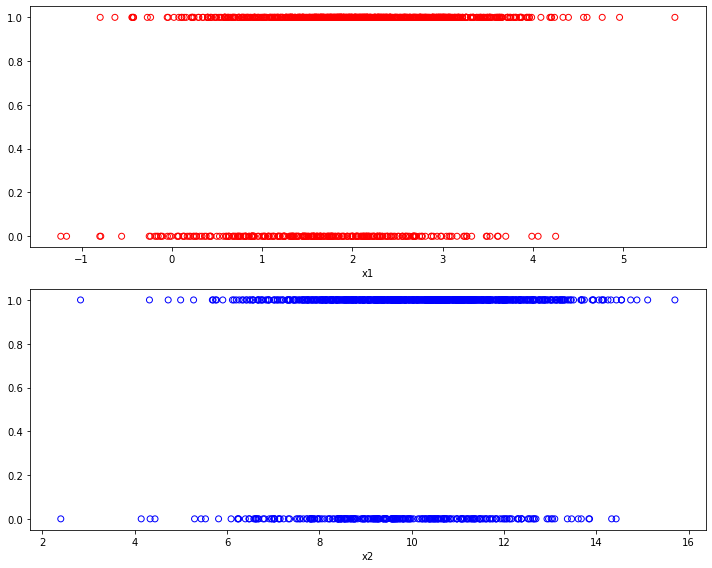

In [8]:
import matplotlib.pyplot as plt
#
fig = plt.figure(figsize = (10, 8))
_ = fig.add_subplot(2, 1, 1).scatter(x1, y, edgecolor = "red", color = "None")
_ = plt.xlabel("x1")
_ = fig.add_subplot(2, 1, 2).scatter(x2, y, edgecolor = "blue", color = "None")
_ = plt.xlabel("x2")
_ = plt.tight_layout()
plt.show()

In [9]:
import statsmodels.formula.api as smf
# Hồi quy OLS y theo x1 và x2
mdl_ols = smf.ols("y ~ 1 + x1 + x2", data = data_mat).fit()
print(mdl_ols.summary2().tables[1])

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


              Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
Intercept  0.174465  0.078411  2.224992  2.630493e-02  0.020594  0.328335
x1         0.108452  0.013679  7.928477  5.919460e-15  0.081609  0.135294
x2         0.033137  0.007145  4.637872  3.988320e-06  0.019116  0.047157


In [10]:
import statsmodels.api as sm
# Ước lượng mô hình logit 
mdl_glm = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.logit())).fit()
print(mdl_glm.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013545e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468995  8.080979e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179230e-06  0.100267  0.253787


In [11]:
mdl_logit_fit = smf.logit("y ~ 1 + x1 + x2", data = data_mat).fit() # Một cách khác để ước lượng hàm logit

Optimization terminated successfully.
         Current function value: 0.554489
         Iterations 6


In [12]:
print(mdl_logit_fit.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013546e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468994  8.080996e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179234e-06  0.100267  0.253787


In [13]:
# tạo ra các dự báo cho y bằng 2 cách
data_predict = pd.DataFrame(
        [np.linspace(start = data_mat["x1"].min(), stop = data_mat["x1"].max(), num = 500),
         np.linspace(start = data_mat["x2"].min(), stop = data_mat["x2"].max(), num = 500)],
         index = ["x1", "x2"]).T
ols_pred = mdl_ols.predict(exog = data_predict)
glm_pred = mdl_glm.predict(exog = data_predict)

In [14]:
data_predict

,x1,x2
0,-1.231055,2.397244
1,-1.217422,2.423905
2,-1.203790,2.450567
3,-1.190157,2.477229
4,-1.176525,2.503890
...,...,...
495,5.517049,15.594769
496,5.530682,15.621430
497,5.544314,15.648092
498,5.557947,15.674754


In [17]:
# tạo ra các dự báo cho y bằng 2 cách
data_predict = pd.DataFrame(
        [np.linspace(start = data_mat["x1"].min(), stop = data_mat["x1"].max(), num = 500),
         np.linspace(start = data_mat["x2"].min(), stop = data_mat["x2"].max(), num = 500)],
         index = ["x1", "x2"]).T
ols_pred = mdl_ols.predict(exog = data_predict)
glm_pred = mdl_glm.predict(exog = data_predict)

In [19]:
data_mat2= pd.DataFrame((ols_pred,glm_pred,prob), index = ["ols_pred", "glm_pred","prob"]).T # tạo ra 1 dataframe chứa cột y,eta, prb, x1,x2
data_mat2.head(20)

,ols_pred,glm_pred,prob
0,0.120391,0.103076,0.539332
1,0.122753,0.104246,0.848863
2,0.125115,0.105427,0.806706
3,0.127477,0.106620,0.461849
4,0.129839,0.107825,0.711085
5,0.132201,0.109042,0.746176
6,0.134563,0.110271,0.426926
7,0.136925,0.111512,0.582208
8,0.139287,0.112766,0.787494
9,0.141649,0.114031,0.514046


In [20]:
x_beta_predict = mdl_glm.predict(exog = data_predict, linear = True)
print(x_beta_predict.head(5))

0   -2.163504
1   -2.150915
2   -2.138327
3   -2.125738
4   -2.113150
dtype: float64


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future vers

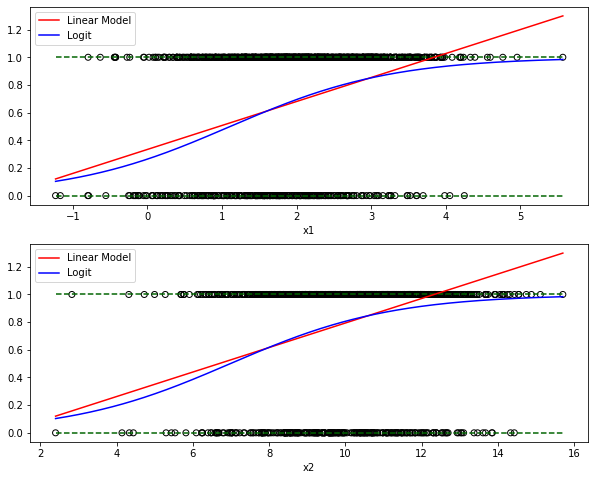

In [21]:
fig = plt.figure(figsize = (10, 8))
for i in range(0, 2):
  j = ["x1", "x2"][i]
  _ = fig.add_subplot(2, 1, i + 1).scatter(data_mat[j], data_mat["y"], 
    edgecolor = "black", color = "None", label = "_nolegend_")
  _ = fig.add_subplot(2, 1, i + 1).plot(data_predict[j], ols_pred, 
    color = "red", label = "Linear Model")
  _ = fig.add_subplot(2, 1, i + 1).plot(data_predict[j], glm_pred, 
    color = "blue", label = "Logit")
  _ = fig.add_subplot(2, 1, i + 1).hlines(y = [0, 1], 
    linestyles = "dashed", color = "darkgreen", label = "_nolegend_",
    xmin = data_predict[j].min(), xmax = data_predict[j].max())
  _ = plt.xlabel(j)
  _ = plt.legend(loc = "upper left")
plt.show()

In [24]:
mdl_logit_fit = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.logit())).fit()
print("1")
print(mdl_logit_fit.summary2().tables[1])
print("2")
print(mdl_logit_fit.params / (np.pi / np.sqrt(3)))
print("3")
mdl_logit_fit = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.logit())).fit()
print(mdl_logit_fit.summary2().tables[1])

1
              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013545e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468995  8.080979e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179230e-06  0.100267  0.253787
2
Intercept   -1.035024
x1           0.318223
x2           0.097600
dtype: float64
3
              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013545e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468995  8.080979e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179230e-06  0.100267  0.253787


In [25]:
mdl_probit_fit = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.probit())).fit()
print(mdl_probit_fit.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.118343  0.251822 -4.441007  8.953902e-06 -1.611905 -0.624781
x1         0.346657  0.045182  7.672487  1.686933e-14  0.258102  0.435212
x2         0.106196  0.023067  4.603716  4.150184e-06  0.060985  0.151407


In [26]:
probit_eta = mdl_probit_fit.predict(exog = data_predict, linear = True)
logit_eta  = mdl_logit_fit.predict(exog = data_predict, linear = True)
print(pd.DataFrame([probit_eta, logit_eta], index = ["probit_eta", "logit_eta"]).T.head(6))

   probit_eta  logit_eta
0   -1.290519  -2.163504
1   -1.282962  -2.150915
2   -1.275405  -2.138327
3   -1.267848  -2.125738
4   -1.260290  -2.113150
5   -1.252733  -2.100562


In [27]:
data_predict = pd.DataFrame(
        [np.linspace(start = data_mat["x1"].min(), stop = data_mat["x1"].max(), num = 100),
         np.linspace(start = data_mat["x2"].min(), stop = data_mat["x2"].max(), num = 100)],
         index = ["x1", "x2"]).T
#
xx1, xx2 = np.meshgrid(data_predict["x1"], data_predict["x2"])
exog = pd.core.frame.DataFrame({'x1': xx1.ravel(), 'x2': xx2.ravel()})
#
logit_pred_tmp  = mdl_logit_fit.predict(exog = exog, linear = False)
probit_pred_tmp = mdl_probit_fit.predict(exog = exog, linear = False)

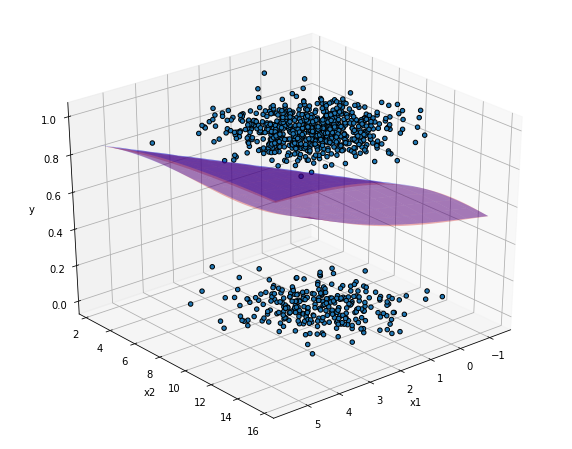

In [28]:
from mpl_toolkits.mplot3d import Axes3D
#
fig = plt.figure(figsize = (10, 8))
ax = fig.gca(projection = '3d')
_ = ax.plot_surface(xx1, xx2, np.reshape(np.array(logit_pred_tmp), xx1.shape), 
                rstride = 8, cstride = 8, color = "red", alpha = 0.3)
_ = ax.plot_surface(xx1, xx2, np.reshape(np.array(probit_pred_tmp), xx1.shape), 
                rstride = 8, cstride = 8, color = "blue", alpha = 0.3)
_ = ax.scatter(data_mat['x1'], data_mat['x2'], data_mat['y'], alpha = 1, edgecolor = "black")
_ = ax.set_xlabel("x1")
_ = ax.set_ylabel("x2")
_ = ax.set_zlabel("y")
_ = ax.view_init(30, 50)
plt.show()

In [33]:
import plotly.offline as py
import plotly.graph_objs as go
#
surface = [go.Surface(x = xx1, y = xx2, z = np.reshape(np.array(logit_pred_tmp), xx1.shape),
                      surfacecolor = np.reshape([0.1] * len(logit_pred_tmp), xx1.shape), 
                      showscale = False, opacity = 0.9, cauto = False, cmax = 1, cmin = 0),
           go.Surface(x = xx1, y = xx2, z = np.reshape(np.array(probit_pred_tmp), xx1.shape),
                      surfacecolor = np.reshape([0.65] * len(probit_pred_tmp), xx1.shape), 
                      showscale = False, cauto = False, cmax = 1, cmin = 0)]
fig = go.Figure(data = surface)
_ = fig.update_layout(width = 500, height = 600)
_ = fig.add_scatter3d(x = data_mat["x1"], y = data_mat["x2"], z = data_mat["y"], 
                mode = 'markers', 
                marker = dict(size = 2, color = [0] * len(data_mat["y"]), colorscale = 'Magma'))
_ = py.plot(fig, filename = "binary_scatter.html", auto_open = True)

In [41]:
fig.show()

In [38]:
from sklearn import metrics
#
tmp_pred = mdl_logit_fit.predict(exog = data_mat)
fpr, tpr, thresholds = metrics.roc_curve(data_mat['y'], tmp_pred)
# as per the documentation, thresholds[0] represents no instances being predicted and is arbitrarily set to max(y_score) + 1 - so we need to drop it
thresholds = thresholds[1:]
fpr = fpr[1:]
tpr = tpr[1:]

In [40]:
misclasserror = []
for k in thresholds:
  # Transform from probability to binary value based on the threshold
  y_pred = np.where(tmp_pred >= k, 1, 0)
  misclasserror.append(1 - metrics.accuracy_score(data_mat['y'], y_pred))
#
# Let's take the first value, which indicates a lower threshold value
optimalCutoff_logit_1 = thresholds[misclasserror == np.min(misclasserror)][0]
print(optimalCutoff_logit_1)

0.44653445164462086


In [42]:
# Tìm ngưỡng tối ưu để cutoff : Nếu tmp_pred> ngưỡng cho y=1, ngược lại =0
misclasserror = []
for k in thresholds:
  # Transform from probability to binary value based on the threshold
  y_pred = np.where(tmp_pred >= k, 1, 0)
  misclasserror.append(1 - metrics.accuracy_score(data_mat['y'], y_pred))
#
# Let's take the first value, which indicates a lower threshold value
optimalCutoff_logit_1 = thresholds[misclasserror == np.min(misclasserror)][0]
print(optimalCutoff_logit_1)

0.44653445164462086


In [43]:
predicted_probs_logit = mdl_logit_fit.predict(exog = data_mat)
tmp_out = metrics.confusion_matrix(mdl_logit_fit.model.endog, 
                               np.where(predicted_probs_logit >= 0.5, 1, 0))
print(pd.DataFrame(tmp_out, 
                   columns = ["Predicted 0", "Predicted 1"],
                   index = ["Actual 0", "Actual 1"]))

          Predicted 0  Predicted 1
Actual 0           32          249
Actual 1           34          685
